## 1. 环境准备

导入必要的库并配置中文字体支持。

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 逻辑回归模型训练与可视化

本部分演示逻辑回归在二分类问题中的应用：
1.  **数据加载**：使用 `load_iris` 加载鸢尾花数据集，并仅保留前两个特征以便可视化。
2.  **数据预处理**：将目标变量转换为二分类问题（0 vs 其他）。
3.  **数据集划分**：按 7:3 比例划分训练集和测试集。
4.  **模型构建**：使用 `LogisticRegression`，配置 L2 正则化。
5.  **模型训练与评估**：训练模型并计算准确率与混淆矩阵。
6.  **决策边界可视化**：绘制分类决策边界，直观展示模型的分类效果。

准确率: 1.0
混淆矩阵:
 [[19  0]
 [ 0 26]]


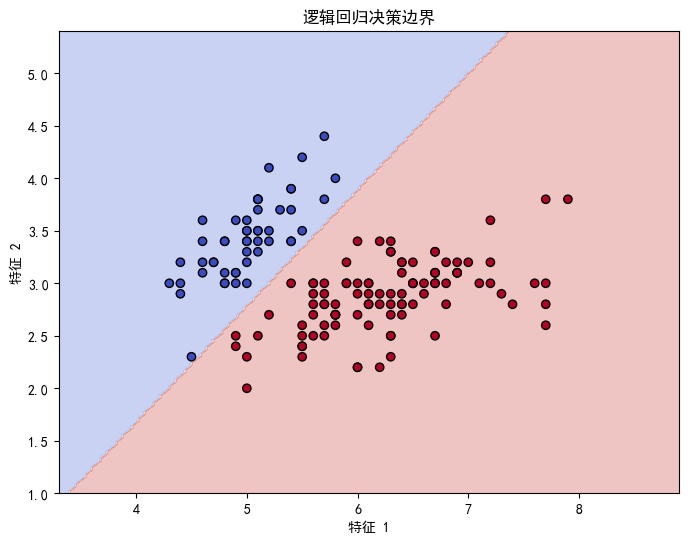

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# 数据加载与预处理
iris = load_iris()
X = iris.data[:, :2]  # 仅使用前两个特征
y = (iris.target != 0).astype(int)  # 二分类问题

# 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 模型训练
model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# 模型评估
y_pred = model.predict(X_test)
print("准确率:", accuracy_score(y_test, y_pred))
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred))

# 可视化决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.title("逻辑回归决策边界")
plt.show()

## 3. 参数解析

代码中使用了 `LogisticRegression(penalty='l2', C=1.0, ...)`，以下是关键参数的详细说明：

### 1. `penalty` (正则化类型)
用于指定正则化项的类型，防止模型过拟合。

- **`'l2'`**(默认)：即岭回归 (Ridge)。
  - 在损失函数中添加权重的**平方和**：$\frac{1}{2} \sum w_j^2$
  - 倾向于让权重普遍变小，但不会减为 0。
  
- **`'l1'`** ：即 Lasso 回归。
  - 在损失函数中添加权重的**绝对值之和**：$\sum |w_j|$
  - 可以让部分特征的权重变为 0，从而实现**特征选择**。

### 2. `C` (正则化强度的倒数)
`C` 是正则化强度的**倒数**，控制模型对训练数据的拟合程度。

$$
\text{总损失} = \text{原始损失} + \frac{1}{C} \times \text{正则化项}
$$

- **`C` 越小**：正则化强度越高。模型容错率更高，权重被压缩得更厉害（可能导致欠拟合）。
- **`C` 越大**：正则化强度越低。模型更试图完美拟合训练数据（可能导致过拟合）。

通常通过交叉验证来寻找最佳的 `C` 值。

## 4. 类别不平衡处理 (Class Imbalance)

在实际场景（如欺诈检测）中，正负样本比例往往极度不平衡。本部分演示两种**不需要安装额外库**（如 imblearn）的处理方法：

1.  **使用 `class_weight='balanced'`**：
    Scikit-learn 的 `LogisticRegression` 提供了一个内置参数 `class_weight`。设置为 `'balanced'` 时，模型会自动根据训练数据中各类的频率计算权重，使少数类样本在损失函数中拥有更大的权重。

2.  **手动过采样 (Upsampling)**：
    使用 Scikit-learn 的 `resample` 工具，对少数类样本进行有放回的随机抽样，增加其数量直至与多数类一致。这种方法简单直观，不需要引入 `SMOTE` 等复杂算法。

原始训练集分布: [668  32]

--- 方法一：使用 class_weight='balanced' ---
分类报告 (class_weight='balanced'):
               precision    recall  f1-score   support

         多数类       0.99      0.97      0.98       277
         少数类       0.72      0.91      0.81        23

    accuracy                           0.97       300
   macro avg       0.86      0.94      0.89       300
weighted avg       0.97      0.97      0.97       300


--- 方法二：手动过采样 (Upsampling) ---
过采样后训练集分布: [668 668]
分类报告 (Manual Upsampling):
               precision    recall  f1-score   support

         多数类       0.99      0.97      0.98       277
         少数类       0.70      0.91      0.79        23

    accuracy                           0.96       300
   macro avg       0.85      0.94      0.89       300
weighted avg       0.97      0.96      0.97       300



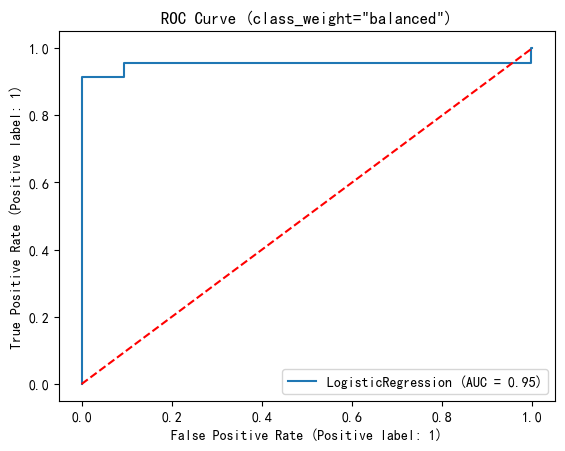

In [28]:
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, RocCurveDisplay
from sklearn.utils import resample

# 1. 生成类别不平衡数据 (95% : 5%)
X_imb, y_imb = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_informative=2, random_state=42,
                           n_clusters_per_class=1, weights=[0.95, 0.05])

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

print(f"原始训练集分布: {np.bincount(y_train_imb)}")

# ================= 方法一：使用 class_weight='balanced' (推荐) =================
print("\n--- 方法一：使用 class_weight='balanced' ---")
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
model_balanced.fit(X_train_imb, y_train_imb)

y_pred_balanced = model_balanced.predict(X_test_imb)
print("分类报告 (class_weight='balanced'):\n", classification_report(y_test_imb, y_pred_balanced, target_names=['多数类', '少数类']))


# ================= 方法二：手动过采样 (Upsampling) =================
print("\n--- 方法二：手动过采样 (Upsampling) ---")
# 1. 合并特征和标签，方便重采样
# 注意：为了演示方便，这里先合并。实际工程中也可以仅对索引进行重采样。
train_data = np.column_stack((X_train_imb, y_train_imb))

# 2. 分离多数类和少数类
majority = train_data[train_data[:, -1] == 0]
minority = train_data[train_data[:, -1] == 1]

# 3. 对少数类进行过采样 (Upsample minority class)
minority_upsampled = resample(minority, 
                              replace=True,     # 允许重复采样 (sample with replacement)
                              n_samples=len(majority),    # 采样数量匹配多数类
                              random_state=42)

# 4. 合并回训练集
train_upsampled = np.vstack((majority, minority_upsampled))
X_train_up = train_upsampled[:, :-1]
y_train_up = train_upsampled[:, -1].astype(int)

print(f"过采样后训练集分布: {np.bincount(y_train_up)}")

# 5. 训练模型 (普通逻辑回归，无需 class_weight)
model_up = LogisticRegression(random_state=42)
model_up.fit(X_train_up, y_train_up)

y_pred_up = model_up.predict(X_test_imb)
print("分类报告 (Manual Upsampling):\n", classification_report(y_test_imb, y_pred_up, target_names=['多数类', '少数类']))

# 绘制 ROC 曲线 (展示方法一的效果)
RocCurveDisplay.from_estimator(model_balanced, X_test_imb, y_test_imb)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.title('ROC Curve (class_weight="balanced")')
plt.show()

## 5. 非线性扩展 (Polynomial Features)

逻辑回归本质是线性分类器。对于非线性可分数据（如环形分布），我们可以通过构造多项式特征来提升模型的表达能力。

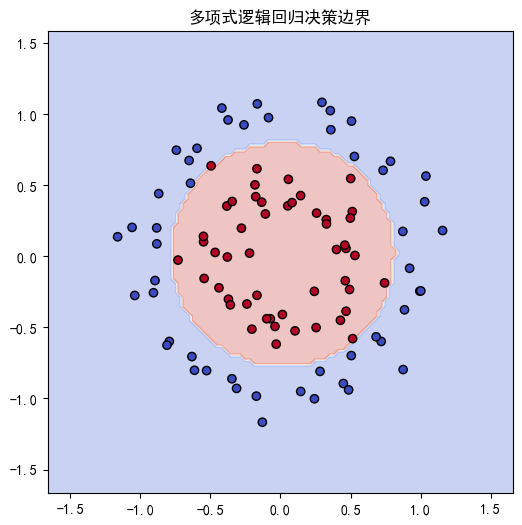

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_circles

# 1. 生成非线性可分数据 (圆形分布)
X_circle, y_circle = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=42)

# 2. 生成多项式特征 (2次项)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_circle)

# 3. 训练逻辑回归
clf_poly = LogisticRegression()
clf_poly.fit(X_poly, y_circle)

# 4. 可视化决策边界
plt.figure(figsize=(6, 6))
x_min, x_max = X_circle[:, 0].min() - 0.5, X_circle[:, 0].max() + 0.5
y_min, y_max = X_circle[:, 1].min() - 0.5, X_circle[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# 预测时同样需要转换特征
Z = clf_poly.predict(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("多项式逻辑回归决策边界")
plt.show()

## 6. 参数调优 (GridSearchCV)

使用网格搜索 (GridSearchCV) 自动寻找最佳的超参数组合（如 `C` 和 `penalty`）。

In [30]:
from sklearn.model_selection import GridSearchCV

# 参数网格
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'] # lbfgs solver 默认支持 l2
}

grid_search = GridSearchCV(LogisticRegression(solver='lbfgs', max_iter=1000), param_grid, cv=5)
grid_search.fit(X_train, y_train) # 使用之前的鸢尾花数据

print("最佳参数:", grid_search.best_params_)
print("最佳交叉验证得分:", grid_search.best_score_)

最佳参数: {'C': 1, 'penalty': 'l2'}
最佳交叉验证得分: 1.0
